# Stage 5: Normalization & Feature Scaling
**Member:** **M5 — IT25103041**
**Assigned Preprocessing Technique:** Standardisation (z-score) fit on training rows
**Dataset:** [US Permanent Visa Applications](https://www.kaggle.com/datasets/jboysen/us-perm-visas) (US Department of Labor, via Kaggle)
**Group:** 2026-Y02-S1-MLB-B9G1-08
**Pipeline Position:** Stage 5 of 6 (sequential)
**Input:** `results/outputs/stage4_features_created.parquet`
**Output:** `results/outputs/stage5_scaled.parquet`

---
## 1. Explanation of the Technique

Scaling puts features on comparable ranges:
1. **Min-max normalisation** to [0, 1] - sensitive to remaining extremes.
2. **Standardisation (z-score)** `z = (x - mean) / std` - zero mean, unit variance; keeps the distribution shape.
3. **Robust scaling** - median / IQR.

Gradient-based models (Logistic Regression, MLP), margin-based models (SVM) and distance-based methods are sensitive to scale; tree models (Decision Tree, Random Forest, XGBoost) are not. The mean and std are learned from **train rows only** and re-used for the test rows (exactly what `StandardScaler.fit(X_train)` does).

---
## 2. Justification for THIS Dataset Specifically

- Wages are in the tens of thousands of USD (train mean USD 93,977, std USD 37,527), log employer size is ~0-12, ordinal education codes are 0-5 and ratios are ~1. Unscaled, an SVM or Logistic Regression penalty would be dominated by the wage columns.
- Outliers were already capped in Stage 3, so standardisation (rather than robust scaling) is appropriate.
- **What is scaled:** the 12 continuous / ordinal columns in `SCALE_COLS`. **Not scaled:** one-hot and binary flags (they stay 0/1 and remain interpretable).
- **Handover B** (scaled) is the default dataset for all six models - tree models are unaffected by scaling, scale-sensitive models need it. The unscaled **handover A** is an optional preprocessing variety.

### Why this must be Stage 5
- After Stage 4, so engineered features are scaled in the same space as the originals.
- Before Stage 6, so the correlation filter and the selected handover-B features are on a common scale.

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

# --- Project paths: search upward for the folder that contains data/raw ---
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, 'data', 'raw')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)

RAW_CSV = os.path.join(ROOT, 'data', 'raw', 'us_perm_visas.csv')
EXT_DIR = os.path.join(ROOT, 'data', 'external')
OUT_DIR = os.path.join(ROOT, 'results', 'outputs')
PLOT_DIR = os.path.join(ROOT, 'results', 'eda_visualizations')
LOG_DIR = os.path.join(ROOT, 'results', 'logs')
for _d in (OUT_DIR, PLOT_DIR, LOG_DIR):
    os.makedirs(_d, exist_ok=True)

# --- Shared settings (identical in every notebook) ---
TARGET = 'denied'            # 1 = Denied, 0 = Certified / Certified-Expired
SEED = 42
TEST_SIZE = 0.20             # stratified 80/20 split; teammates use 5-fold CV on the train rows
DEV_SAMPLE = None            # e.g. 0.10 for a fast ~35k-row run; None = full dataset
EDA_ONLY_COLS = ['case_status', 'decision_date']                          # kept for EDA, dropped in S6
LEAKAGE_COLS = ['case_id', 'case_received_date', 'application_type', 'processing_days']  # must never reach a model
NON_FEATURE_COLS = EDA_ONLY_COLS + [TARGET, 'split']

REFERENCE_YEAR = 2016                                                     # last year in the dataset
S4_PASSTHROUGH = ['employer_state', 'job_info_work_state', 'agent_firm_name']  # raw columns kept by S2 for S4
SCALE_COLS = ['wage_offer_annual', 'pw_annual', 'wage_gap_annual', 'wage_to_pw_ratio',  # continuous / ordinal
              'employer_num_employees_log', 'employer_filing_count_log', 'employer_yr_estab', 'employer_age',
              'pw_level', 'edu_worker', 'edu_required', 'edu_gap']

# --- Reference tables (data/external) ---
_states = pd.read_csv(os.path.join(EXT_DIR, 'us_states.csv'))
STATE_LOOKUP = {**dict(zip(_states['state_name'], _states['state_code'])),
                **dict(zip(_states['state_code'], _states['state_code']))}
STATE_REGION = dict(zip(_states['state_code'], _states['census_region']))
VALID_SOC = set(pd.read_csv(os.path.join(EXT_DIR, 'soc_major_groups.csv'), dtype=str)['soc_major_group'])
_naics = pd.read_csv(os.path.join(EXT_DIR, 'naics_sectors.csv'), dtype=str)
VALID_NAICS = set(_naics['naics_2digit'])
NAICS_SECTOR_KEY = dict(zip(_naics['naics_2digit'], _naics['sector_key']))

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'Project root: {ROOT}')

Project root: /Users/jathushansundararasu/Desktop/us_prem_visa


In [2]:
# ==============================================================================
# STAGE 5: Normalization & Feature Scaling (M5)
# ==============================================================================


def stage5_feature_scaling(df, plot_dir=PLOT_DIR, out_dir=OUT_DIR, show_plot=False):
    """Z-score standardisation with mean / std computed on TRAIN rows only; binary and one-hot columns stay 0/1."""
    d = df.copy()
    train = d['split'].eq('train')
    mu = d.loc[train, SCALE_COLS].mean()
    sigma = d.loc[train, SCALE_COLS].std().replace(0, 1.0)
    d[SCALE_COLS] = ((d[SCALE_COLS] - mu) / sigma).astype('float32')
    if out_dir:
        pd.DataFrame({'column': SCALE_COLS, 'train_mean': mu.values, 'train_std': sigma.values}).to_csv(
            os.path.join(out_dir, 'scaler_params.csv'), index=False)

    if plot_dir:
        fig, axes = plt.subplots(2, 2, figsize=(14, 9))
        plt.subplots_adjust(hspace=0.4, wspace=0.25)
        for i, (col, unit) in enumerate([('wage_offer_annual', 'USD / year'), ('employer_num_employees_log', 'log(1 + employees)')]):
            before, after = df.loc[train, col], d.loc[train, col]
            axes[i, 0].hist(before, bins=40, color='#3498db', edgecolor='black')
            axes[i, 0].set_title(f'Before: {col}\nmean {before.mean():,.2f} | std {before.std():,.2f}', fontweight='bold')
            axes[i, 0].set_xlabel(unit)
            axes[i, 1].hist(after, bins=40, color='#2ecc71', edgecolor='black')
            axes[i, 1].set_title(f'After z-score: {col}\nmean {after.mean():.2f} | std {after.std():.2f}', fontweight='bold')
            axes[i, 1].set_xlabel('z-score')
        plt.suptitle('m5: Standardisation (train mean / std) - shape preserved, scale aligned', fontsize=14, fontweight='bold', y=1.03)
        plt.savefig(f'{plot_dir}/m5_scaling_comparison.png', dpi=200, bbox_inches='tight')
        plt.show() if show_plot else plt.close()
    return d

Loaded Stage 4 data: 354,849 rows x 111 columns


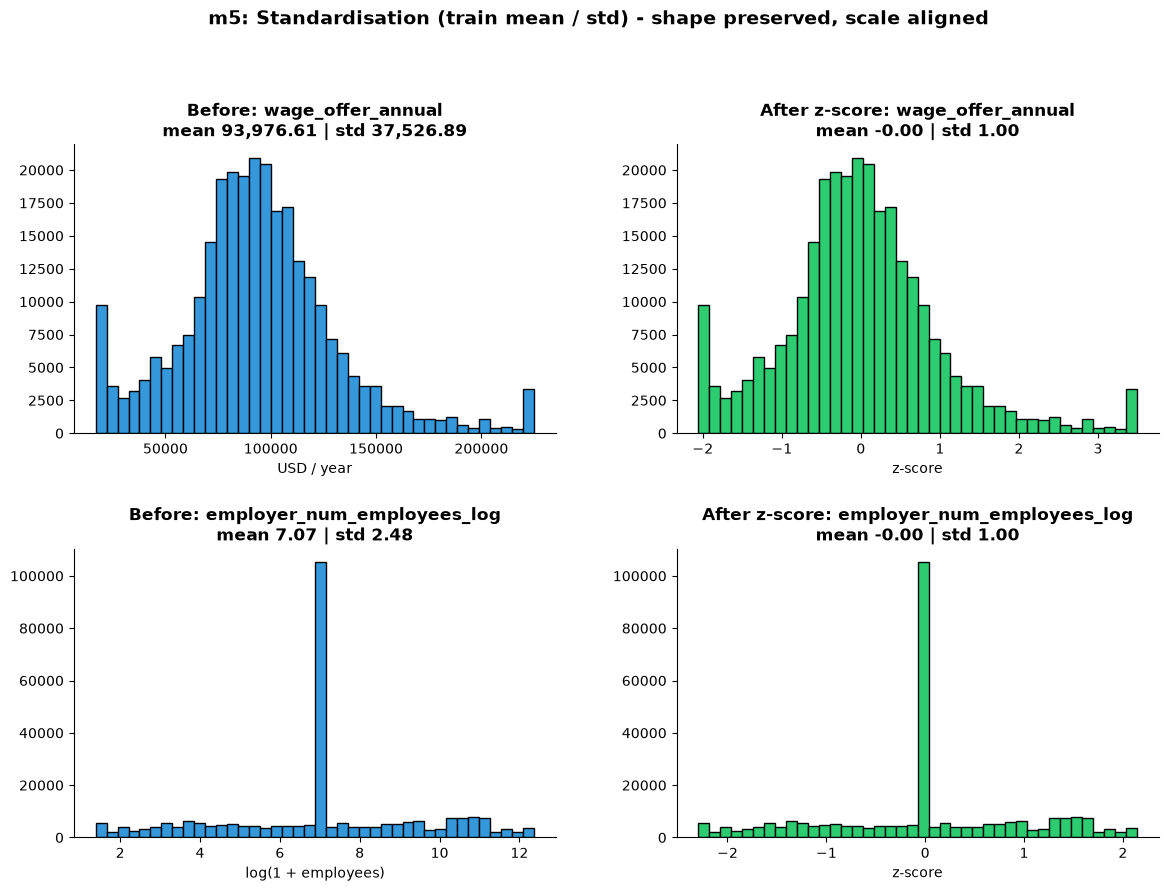

Saved Stage 5 output: 354,849 rows x 111 columns


In [3]:
# 1. Load Stage 4 output and standardise (+ EDA plot m5)
df_4 = pd.read_parquet(os.path.join(OUT_DIR, 'stage4_features_created.parquet'))
print(f'Loaded Stage 4 data: {df_4.shape[0]:,} rows x {df_4.shape[1]} columns')
df_5 = stage5_feature_scaling(df_4, show_plot=True)
df_5.to_parquet(os.path.join(OUT_DIR, 'stage5_scaled.parquet'), index=False)
print(f'Saved Stage 5 output: {df_5.shape[0]:,} rows x {df_5.shape[1]} columns')

In [4]:
# 2. Verification ("done when" checks)
train = df_5['split'].eq('train')
assert df_5.loc[train, SCALE_COLS].mean().abs().max() < 1e-3, 'train means should be ~0'
assert (df_5.loc[train, SCALE_COLS].std() - 1).abs().max() < 1e-3, 'train stds should be ~1'
unscaled = [c for c in df_5.columns if c not in SCALE_COLS + NON_FEATURE_COLS]
assert df_5[unscaled].equals(df_4[unscaled]), 'binary / one-hot columns must be unchanged'
print('Test-split means (expected close to, but not exactly, 0):')
print(df_5.loc[~train, SCALE_COLS].mean().round(3).to_dict())
print('All Stage 5 checks passed.')

Test-split means (expected close to, but not exactly, 0):
{'wage_offer_annual': -0.004000000189989805, 'pw_annual': -0.004999999888241291, 'wage_gap_annual': -0.0, 'wage_to_pw_ratio': 0.0020000000949949026, 'employer_num_employees_log': -0.0, 'employer_filing_count_log': -0.007000000216066837, 'employer_yr_estab': -0.0020000000949949026, 'employer_age': 0.0020000000949949026, 'pw_level': -0.003000000026077032, 'edu_worker': -0.003000000026077032, 'edu_required': -0.004000000189989805, 'edu_gap': -0.0010000000474974513}
All Stage 5 checks passed.


## 3. EDA Interpretation & Findings

1. **Scale alignment:** before scaling, the offered wage had mean USD 93,977 (std USD 37,527) while log employer size had mean 7.07 (std 2.48). After standardisation every scaled column has mean 0.00 and std 1.00 on the training rows.
2. **Shape preserved:** the histograms keep the same shape - standardisation only shifts and rescales the axis.
3. **Test rows are close to, not exactly, 0 / 1** - expected and correct, because the test split was scaled with the *training* statistics (no leakage).
4. **Hand-off to Stage 6:** scaled data feeds handover B; the unscaled Stage 4 data becomes handover A.